# Tree visualization and clinical interpretability
---
Decision Tree Methods for Clinical Heart Disease Classification. A comparison study of unpruned CART, pruned CART and conditional inference tree classification.


In [9]:
# Loads
#from citrees import ConditionalInferenceTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
from joblib import Parallel, delayed

In [3]:
# Config
seed = random.seed(42)
cv_folds = 5

## Data load

In [7]:
url = "https://archive.ics.uci.edu/static/public/45/data.csv"
df = pd.read_csv("~/Documentos/Master/ADM/ADM_proj_2/data.csv")


y = df['num']


cols_to_drop = ['num']
X = df.drop(columns=cols_to_drop)

print("--- Features (X) ---")
print(X.head())
print("\n--- Target (y) ---")
print(y.head())

--- Features (X) ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

--- Target (y) ---
0    0
1    2
2    1
3    0
4    0
Name: num, dtype: int64


## Unpruned CART

Tree Depth: 14
Total Leaves: 102
Scores for each fold: [0.40983607 0.60655738 0.47540984 0.46666667 0.51666667]
Mean CV Accuracy: 0.4950
|--- thal <= 4.50
|   |--- ca <= 0.50
|   |   |--- trestbps <= 157.00
|   |   |   |--- thalach <= 83.50
|   |   |   |   |--- class: 2
|   |   |   |--- thalach >  83.50
|   |   |   |   |--- oldpeak <= 3.55
|   |   |   |   |   |--- age <= 59.50
|   |   |   |   |   |   |--- oldpeak <= 1.70
|   |   |   |   |   |   |   |--- trestbps <= 109.00
|   |   |   |   |   |   |   |   |--- sex <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- sex >  0.50
|   |   |   |   |   |   |   |   |   |--- chol <= 232.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- chol >  232.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- trestbps >  109.00
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- oldpeak >  1.70
|   |   |   

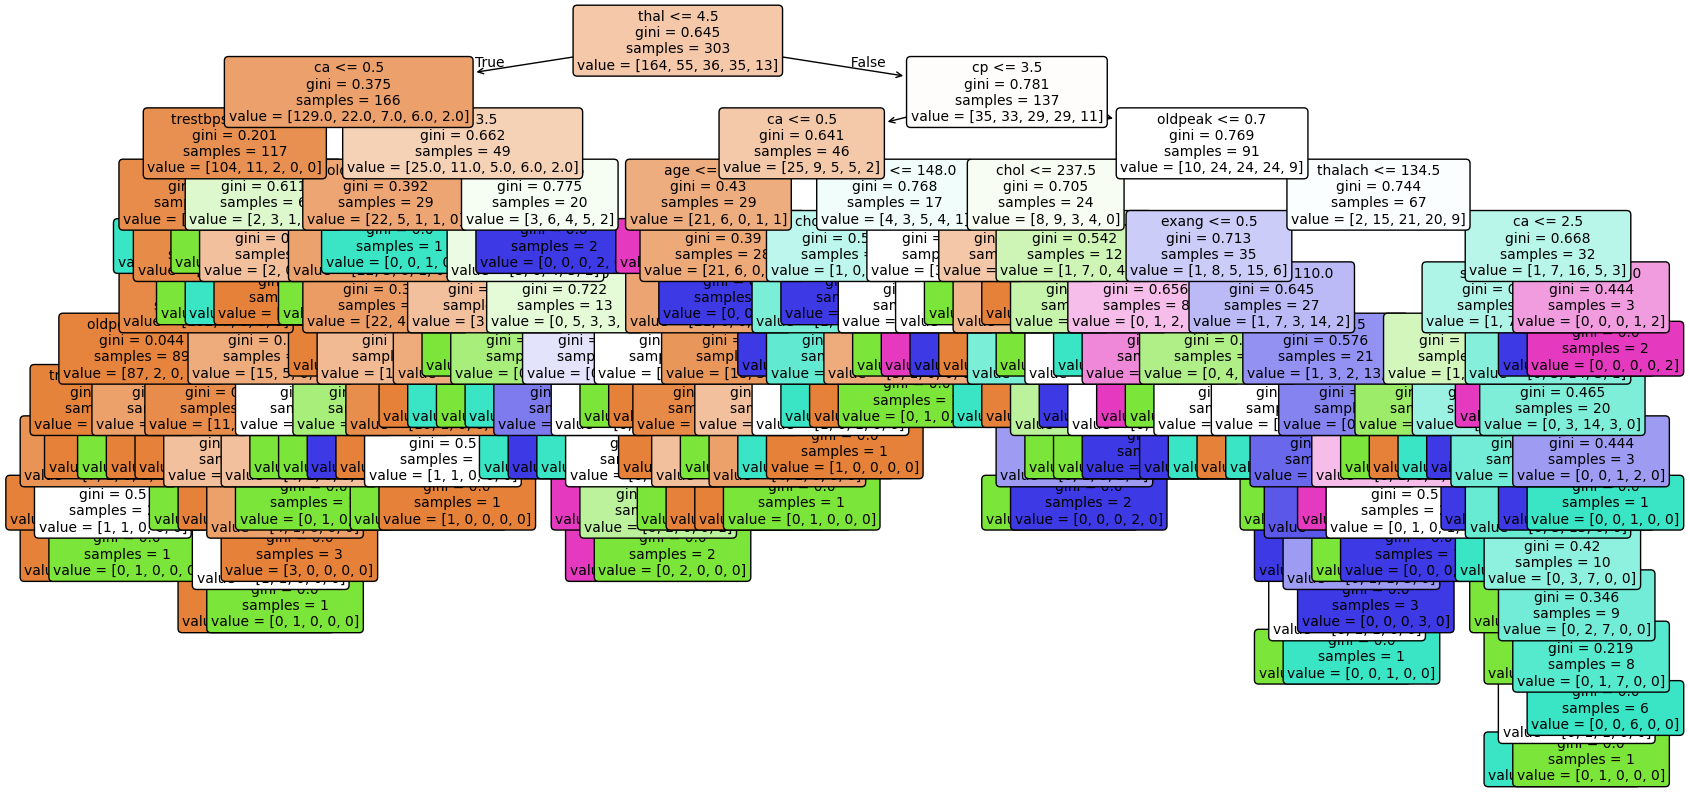

In [10]:
# Create Decision Tree Regressor
tree_regressor = DecisionTreeClassifier(random_state=seed)

# 1. Fit on full dataset to inspect tree structure
tree_regressor.fit(X, y)

depth = tree_regressor.get_depth()
num_leaves = tree_regressor.get_n_leaves()
print(f"Tree Depth: {depth}")
print(f"Total Leaves: {num_leaves}")

# 2. Separately run 5-fold CV (fits its own internal copies of the model)
cv_scores = cross_val_score(tree_regressor, X, y, cv=cv_folds)
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

tree_rules = export_text(tree_regressor, feature_names=list(X.columns))
print(tree_rules)

plt.figure(figsize=(20, 10))
plot_tree(tree_regressor, 
          feature_names=list(X.columns), 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

## Pruned CARTs 

Total alphas to evaluate: 63


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  39 out of  63 | elapsed:    2.2s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done  46 out of  63 | elapsed:    2.2s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done  53 out of  63 | elapsed:    2.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  60 out of  63 | elapsed:    2.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  63 out of  63 | elapsed:    2.5s finished


Best alpha: 0.0184, Best CV R²: 0.5477
Tree Depth: 5
Total Leaves: 12
Scores for each fold: [ 0.2853886   0.35901912  0.29254009  0.25429124 -0.31578247]
Mean CV R²: 0.1751
|--- thal <= 4.50
|   |--- ca <= 0.50
|   |   |--- value: [0.14]
|   |--- ca >  0.50
|   |   |--- cp <= 3.50
|   |   |   |--- value: [0.34]
|   |   |--- cp >  3.50
|   |   |   |--- exang <= 0.50
|   |   |   |   |--- value: [1.11]
|   |   |   |--- exang >  0.50
|   |   |   |   |--- value: [2.45]
|--- thal >  4.50
|   |--- oldpeak <= 0.70
|   |   |--- ca <= 0.50
|   |   |   |--- value: [0.38]
|   |   |--- ca >  0.50
|   |   |   |--- age <= 49.00
|   |   |   |   |--- value: [3.00]
|   |   |   |--- age >  49.00
|   |   |   |   |--- value: [1.18]
|   |--- oldpeak >  0.70
|   |   |--- oldpeak <= 2.35
|   |   |   |--- cp <= 3.50
|   |   |   |   |--- thalach <= 150.50
|   |   |   |   |   |--- value: [1.64]
|   |   |   |   |--- thalach >  150.50
|   |   |   |   |   |--- value: [0.12]
|   |   |   |--- cp >  3.50
|   |   |   |

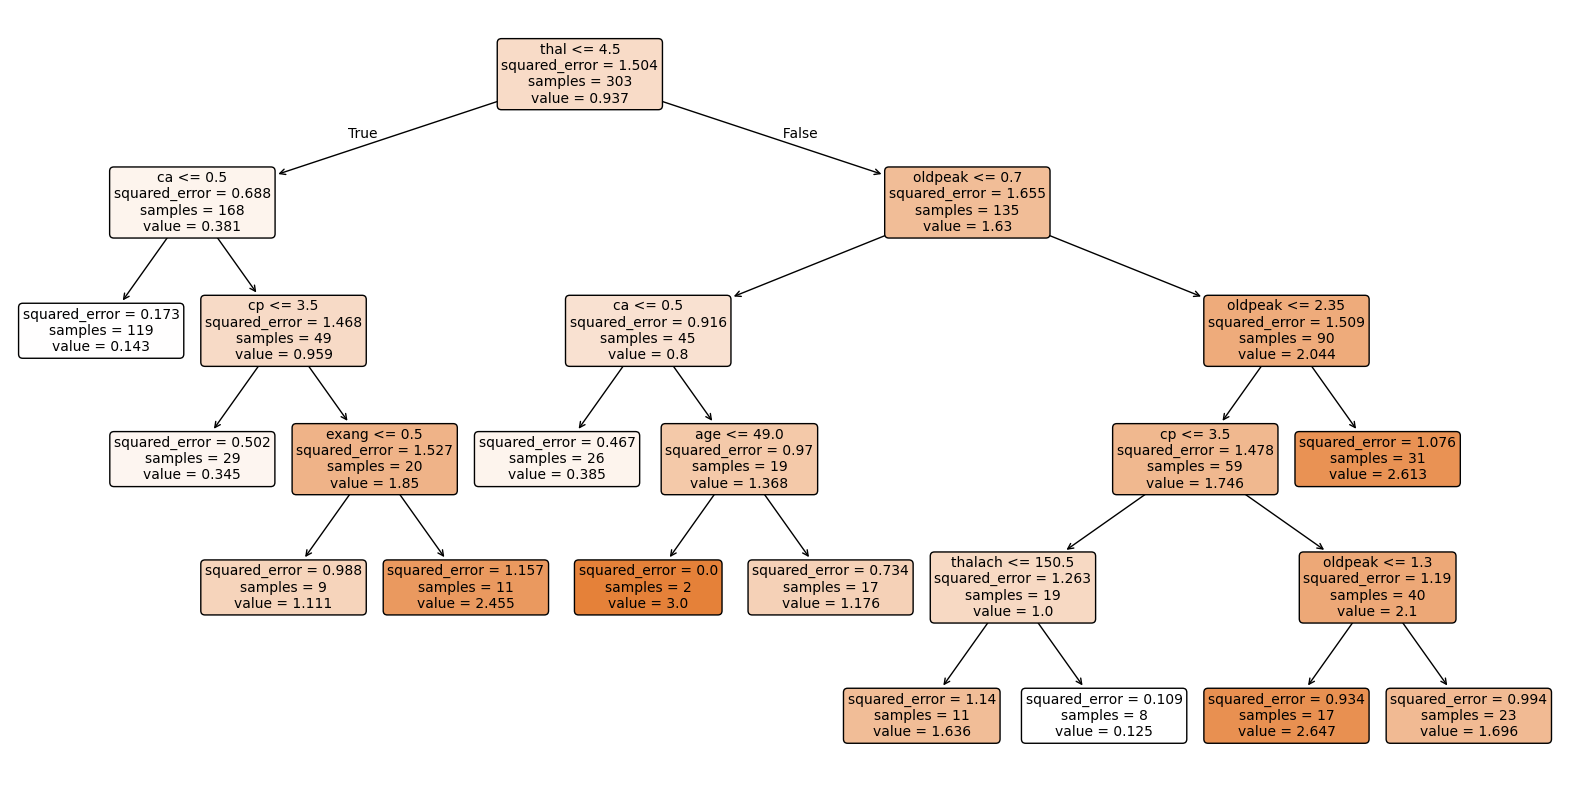

In [11]:
path = tree_regressor.cost_complexity_pruning_path(X, y)
alphas = path.ccp_alphas
print(f"Total alphas to evaluate: {len(alphas)}")

def evaluate_alpha(alpha, X, y, cv_folds, seed):
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=seed)
    # n_jobs=-1 parallelises the CV folds too
    scores = cross_val_score(dt, X, y, cv=cv_folds, n_jobs=-1)
    return alpha, scores.mean()

# Parallelise across all alphas using all available CPU cores
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(evaluate_alpha)(alpha, X, y, cv_folds, seed)
    for alpha in alphas
)

# Find best alpha from results
best_alpha, best_score = max(results, key=lambda x: x[1])
print(f"Best alpha: {best_alpha:.4f}, Best CV R²: {best_score:.4f}")

# Refit pruned tree
pruned_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=seed)
pruned_tree.fit(X, y)

depth = pruned_tree.get_depth()
num_leaves = pruned_tree.get_n_leaves()
print(f"Tree Depth: {depth}")
print(f"Total Leaves: {num_leaves}")

cv_scores = cross_val_score(pruned_tree, X, y, cv=cv_folds, n_jobs=-1)
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

tree_rules = export_text(pruned_tree, feature_names=list(X.columns))
print(tree_rules)

plt.figure(figsize=(20, 10))
plot_tree(pruned_tree,
          feature_names=list(X.columns),
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

## Conditional inference tree
NO VA

In [27]:
clf = ConditionalInferenceTreeClassifier(
    selector="mc",
    splitter="gini",
    alpha_selector=0.05,  
    alpha_splitter=0.05,  
    random_state=seed
)
clf.fit(X, y)

,selector,'mc'
,splitter,'gini'
,alpha_selector,0.05
,alpha_splitter,0.05
,adjust_alpha_selector,True
,adjust_alpha_splitter,True
,n_resamples_selector,'auto'
,n_resamples_splitter,'auto'
,early_stopping_selector,'adaptive'
,early_stopping_splitter,'adaptive'
,early_stopping_confidence_selector,0.95


In [28]:
cv_scores = cross_val_score(clf, X, y, cv=cv_folds, n_jobs=-1)
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

/home/ariadna/Documentos/Master/ADM/my_env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Scores for each fold: [0.29027618 0.26812428 0.29746835 0.29401611 0.30388489]
Mean CV R²: 0.2908
